<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_KOMPUTASI_KEUANGAN/blob/main/SIMULASI_BINOMIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

/tmp/ipykernel_806/4262236744.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


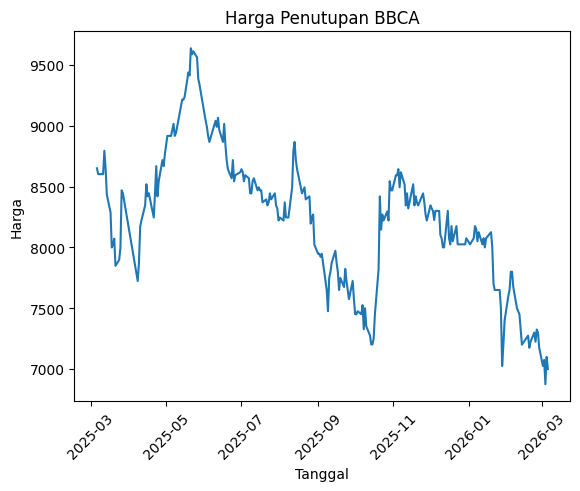

In [ ]:
# ==============================
# Ambil Data BBCA 1 Tahun
# ==============================

ticker = "BBCA.JK"
data = yf.download(ticker, period="1y")

# Jika kolom berbentuk MultiIndex (ada level ticker), ambil level pertama saja
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Reset index supaya Date jadi kolom biasa
data = data.reset_index()

# Pakai harga penutupan
prices = data['Close']

# Perhitungan Log Return
log_return = np.log(prices / prices.shift(1)).dropna()

# Plot harga penutupan saham BBCA
plt.figure()
plt.plot(data['Date'], prices)
plt.title("Harga Penutupan BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# PARAMETER SIMULASI
# ==============================

T = 1          # horizon waktu (1 tahun)
L = 252        # jumlah langkah waktu (hari trading)
dt = T / L     # panjang interval waktu
S0 = prices.iloc[-1].item() # Harga awal simulasi

# ==============================
# Hitung Variansi log return
# ==============================
var_log = log_return.var()

# Estimasi sigma sesuai formula
sigma = (1/np.sqrt(dt)) * np.sqrt(var_log)

# ==============================
# Hitung mean log return
# ==============================
mean_log = log_return.mean()

# Estimasi mu sesuai formula
mu = (1/dt)*mean_log + 0.5*sigma**2

print("S0: ", S0)
print("mu: ", mu)
print("sigma: ", sigma)

S0:  7000.0
mu:  -0.18500652919290542
sigma:  0.28628841314371417


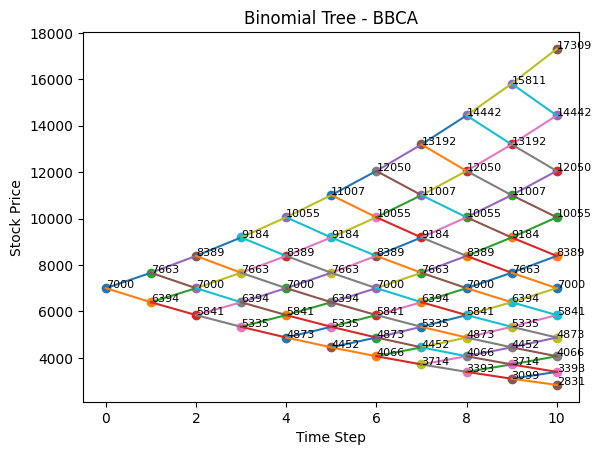

In [ ]:
# ==============================
# VISUALISASI BINOMIAL TREE
# ==============================
N_plot = 10
dt = T / N_plot

u = np.exp(sigma * np.sqrt(dt))
d = np.exp(-sigma * np.sqrt(dt))

# ==============================
# BUILD TREE MATRIX
# ==============================
tree = []

for i in range(N_plot + 1):
    level = []
    for j in range(i + 1):
        price = S0 * (u**j) * (d**(i - j))
        level.append(price)
    tree.append(level)

# ==============================
# PLOT TREE
# ==============================
plt.figure()

for i in range(N_plot + 1):
    for j in range(i + 1):
        plt.scatter(i, tree[i][j])
        plt.text(i, tree[i][j], f"{tree[i][j]:.0f}", fontsize=8)

        if i < N_plot:
            # garis ke atas
            plt.plot([i, i+1],
                     [tree[i][j], S0*(u**(j+1))*(d**(i-j))])

            # garis ke bawah
            plt.plot([i, i+1],
                     [tree[i][j], S0*(u**j)*(d**(i-j+1))])

plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.title("Binomial Tree - BBCA")
plt.show()

**SIMULASI PERHITUNGAN HARGA OPSI MENGGUNAKAN METODE BINOMIAL DAN BLACK-SHOLES**

In [ ]:
import numpy as np
from scipy.stats import norm

# ==============================
# PARAMETER OPSI
# ==============================
S0 = 7350
K_values = [7000, 7350, 7700]
r = 0.0475
sigma = 0.2873413575813813
T = 1
N = 252

# ==============================
# BINOMIAL EUROPEAN OPTION
# ==============================
def binomial_european(S0, K, r, sigma, T, N, option_type):

    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))

    p = (np.exp(r*dt) - d) / (u - d)

    S = np.array([S0*(u**j)*(d**(N-j)) for j in range(N+1)])

    if option_type == "call":
        V = np.maximum(S-K,0)
    else:
        V = np.maximum(K-S,0)

    for i in range(N-1,-1,-1):
        V = np.exp(-r*dt)*(p*V[1:i+2] + (1-p)*V[0:i+1])

    return V[0]


# ==============================
# BINOMIAL AMERICAN OPTION
# ==============================
def binomial_american(S0, K, r, sigma, T, N, option_type):

    dt = T/N
    u = np.exp(sigma*np.sqrt(dt))
    d = np.exp(-sigma*np.sqrt(dt))

    p = (np.exp(r*dt)-d)/(u-d)

    S = np.array([S0*(u**j)*(d**(N-j)) for j in range(N+1)])

    if option_type == "call":
        V = np.maximum(S-K,0)
    else:
        V = np.maximum(K-S,0)

    for i in range(N-1,-1,-1):

        S = np.array([S0*(u**j)*(d**(i-j)) for j in range(i+1)])

        continuation = np.exp(-r*dt)*(p*V[1:i+2] + (1-p)*V[0:i+1])

        if option_type == "call":
            exercise = np.maximum(S-K,0)
        else:
            exercise = np.maximum(K-S,0)

        V = np.maximum(continuation, exercise)

    return V[0]


# ==============================
# BLACK-SCHOLES
# ==============================
def black_scholes(S0, K, r, sigma, T, option_type):

    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

    return price


# ==============================
# PERHITUNGAN
# ==============================
for K in K_values:

    call_euro = binomial_european(S0,K,r,sigma,T,N,"call")
    call_amer = binomial_american(S0,K,r,sigma,T,N,"call")
    call_bs = black_scholes(S0,K,r,sigma,T,"call")

    put_euro = binomial_european(S0,K,r,sigma,T,N,"put")
    put_amer = binomial_american(S0,K,r,sigma,T,N,"put")
    put_bs = black_scholes(S0,K,r,sigma,T,"put")

    print("\n=======================")
    print("Strike =",K)

    print("\nCALL OPTION")
    print("European Binomial :",call_euro)
    print("American Binomial :",call_amer)
    print("Black-Scholes     :",call_bs)

    print("\nPUT OPTION")
    print("European Binomial :",put_euro)
    print("American Binomial :",put_amer)
    print("Black-Scholes     :",put_bs)


Strike = 7000

CALL OPTION
European Binomial : 1183.2829958909313
American Binomial : 1183.2829958909313
Black-Scholes     : 1182.7001848760665

PUT OPTION
European Binomial : 508.5563078191818
American Binomial : 533.5935737610174
Black-Scholes     : 507.9734968044504

Strike = 7350

CALL OPTION
European Binomial : 1000.943962826925
American Binomial : 1000.943962826925
Black-Scholes     : 1001.7677130919192

PUT OPTION
European Binomial : 659.9809403515977
American Binomial : 696.109530087894
Black-Scholes     : 660.8046906167219

Strike = 7700

CALL OPTION
European Binomial : 843.3245949263232
American Binomial : 843.3245949263232
Black-Scholes     : 842.8534352745683

PUT OPTION
European Binomial : 836.1252380474174
American Binomial : 885.4706964113791
Black-Scholes     : 835.6540783957912


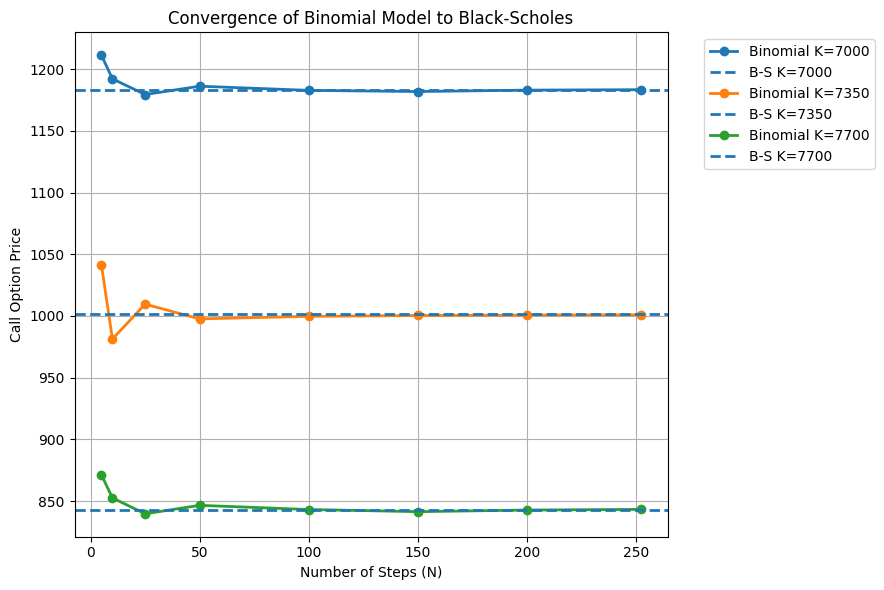

In [ ]:
import matplotlib.pyplot as plt

# variasi jumlah langkah
N_values = [5,10,25,50,100,150,200,252]

plt.figure(figsize=(9,6))

for K in K_values:

    bin_prices = []

    for N in N_values:
        price = binomial_european(S0,K,r,sigma,T,N,"call")
        bin_prices.append(price)

    bs_price = black_scholes(S0,K,r,sigma,T,"call")

    plt.plot(N_values,bin_prices,marker='o',linewidth=2,label=f"Binomial K={K}")
    plt.axhline(bs_price,linestyle='--',linewidth=2,label=f"B-S K={K}")

plt.xlabel("Number of Steps (N)")
plt.ylabel("Call Option Price")
plt.title("Convergence of Binomial Model to Black-Scholes")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")

plt.tight_layout()
plt.show()

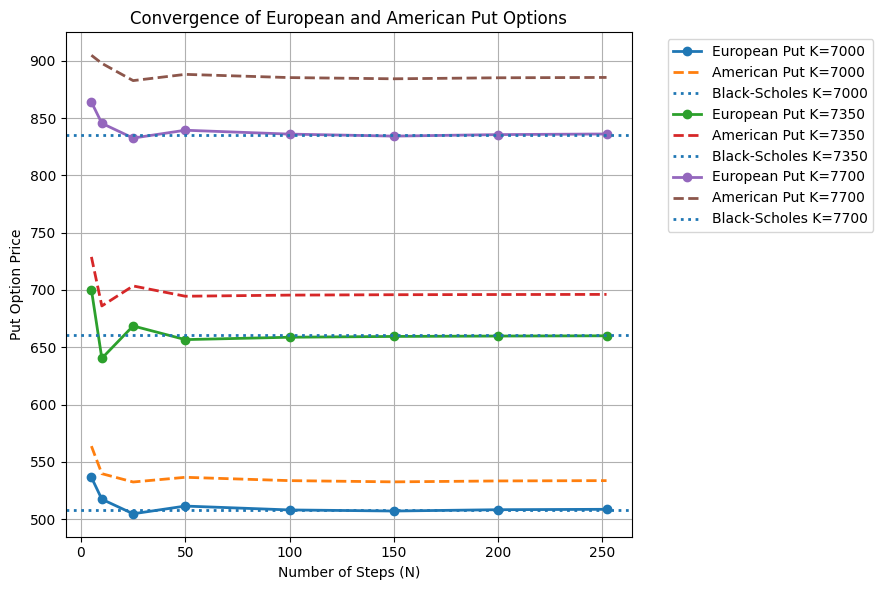

In [ ]:
import matplotlib.pyplot as plt

N_values = [5,10,25,50,100,150,200,252]

plt.figure(figsize=(9,6))

for K in K_values:

    euro_prices = []
    amer_prices = []

    for N in N_values:

        euro = binomial_european(S0, K, r, sigma, T, N, "put")
        amer = binomial_american(S0, K, r, sigma, T, N, "put")

        euro_prices.append(euro)
        amer_prices.append(amer)

    bs_price = black_scholes(S0, K, r, sigma, T, "put")

    # European Put
    plt.plot(N_values, euro_prices, marker='o', linewidth=2,
             label=f"European Put K={K}")

    # American Put
    plt.plot(N_values, amer_prices, linestyle='--', linewidth=2,
             label=f"American Put K={K}")

    # Black-Scholes
    plt.axhline(bs_price, linestyle=':', linewidth=2,
                label=f"Black-Scholes K={K}")

plt.xlabel("Number of Steps (N)")
plt.ylabel("Put Option Price")
plt.title("Convergence of European and American Put Options")
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()